# **X-ray Reflection spectroscopy**

The geometrical configuration, models avaliable and an example of analyzing data.

Contact: honghui.liu\<at\>uni-tuebingen.de

## Material

- First broad iron line calculated for accreting black holes: Fabian et al, 1989, MNRAS, 238, 729 [link](https://ui.adsabs.harvard.edu/abs/1989MNRAS.238..729F/abstract)
- First broad iron line detected: Tanaka et al, 1995, Nature, 375, 659 [link](https://ui.adsabs.harvard.edu/abs/1995Natur.375..659T/abstract)
- X-ray reflection spectroscopy for black hole spins: Reynolds 2014, SSRv, 183, 277 [link](https://ui.adsabs.harvard.edu/abs/2014SSRv..183..277R/abstract); Bambi et al. 2021, SSRv, 217, 65B [link](https://ui.adsabs.harvard.edu/abs/2021SSRv..217...65B/abstract); 

## The disk-corona system

<img src="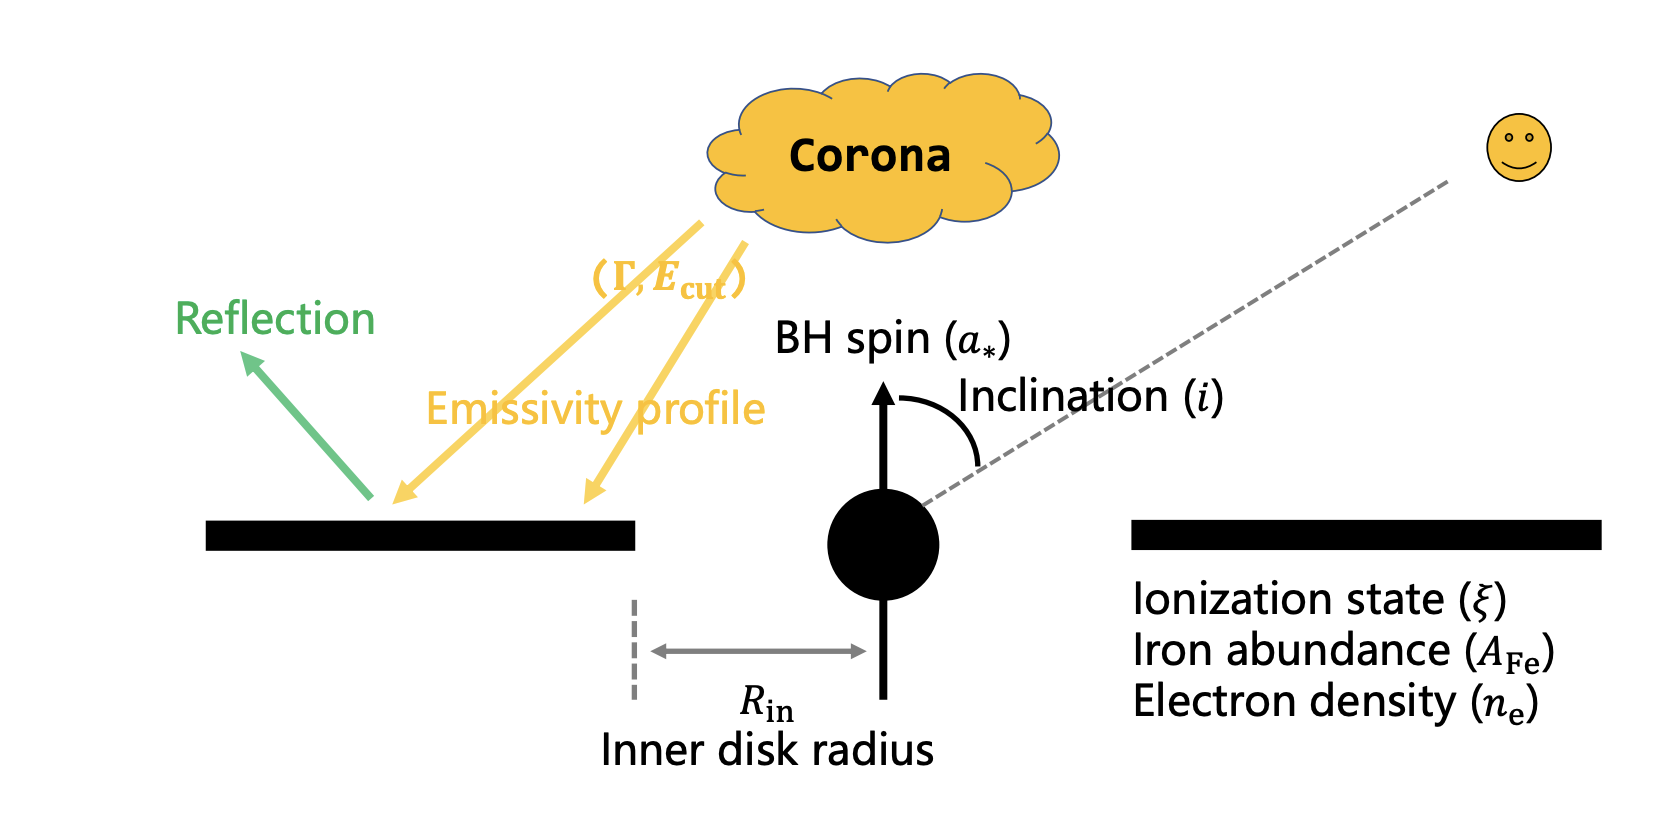
" alt="My plot" width="800"/>

**Figure 1. The disk-corona system and the parameters required to calculate the full reflection spectrum.**

It is necessary to know how the incident radiation is distributed on the disk. Or equivalently, the intensity of the incident radiation as a function of disk radius (the emissivity profile). In principle, this distribution can be self-consistently calculated if the disk-corona geometry is known (e.g. if the corona is a point source above a black hole with spin $a_{*}$ at height $h$). Here the corona is the X-ray source illuminating the accretion disk (the source that emits the power-law radiation to the accretion disk). In practice, a phenomenological emissivity profile in the form of broken power-law is commenly used to fit the reflection spectra. Please distinguish the power-law emission from the corona and the power-law-like emissivity profile! Power-law is just a kind of function that has format: $f(x)=ax^{-k}$.

Then, the disk geometry and its physical properties (inclination, inner and outer radius, density, temperature, ionization, element abundances) are also key ingredients. The inclination of the inner disk, together with the inner radius, will affect the strength of Doppler shifting on the photons emitted from the disk. The inner radius of the disk is also important, because there the gravitational redshift of the photons is the strongest.

The last component is the spacetime. The photons emitted in the vicinity of black holes will inevitably affected by the strong gravity field. This must be taken into account when modeling the reflected spectra from the inner accretion disk. It is also for this reason that the relativistic reflection spectrum can be used to probe the strong gravity field (e.g., measure the black hole spin) and to test gravity theory. For a Kerr black hole, the spacetime metric can be fully described by three parameters: black hole mass ($M$), black hole spin ($a_{*}$) and electric charge ($Q$). The influence of electric charge on the reflection spectrum is negligible. The black hole mass is not needed in the calculation of reflection spectrum when measuring length scale in gravitational radius ($r_g=GM/c^2$). In the end, there is only one parameter, the black hole spin ($a_*$), left in the reflection model.



In [1]:
import xspec
xspec.AllModels.lmod("relxill", '/Users/honghui/projects/models/relxill')

model =  xspec.Model("relxill")

Model package relxill successfully loaded.
 *** loading RELXILL model (version 2.5) *** 

Model relxill<1> Source No.: 1   Active/Off
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   relxill    Index1              3.00000      frozen
   2    1   relxill    Index2              3.00000      frozen
   3    1   relxill    Rbr                 15.0000      frozen
   4    1   relxill    a                   0.998000     +/-  0.0          
   5    1   relxill    Incl       deg      30.0000      +/-  0.0          
   6    1   relxill    Rin                 -1.00000     frozen
   7    1   relxill    Rout                400.000      frozen
   8    1   relxill    z                   0.0          frozen
   9    1   relxill    gamma               2.00000      +/-  0.0          
  10    1   relxill    logxi               3.10000      +/-  0.0          
  11    1   relxill    Afe                 1.00000      +/-  0.0          
  12    1   relxill    Ecut       keV      300.000   

## Local reflection and relativistic effects

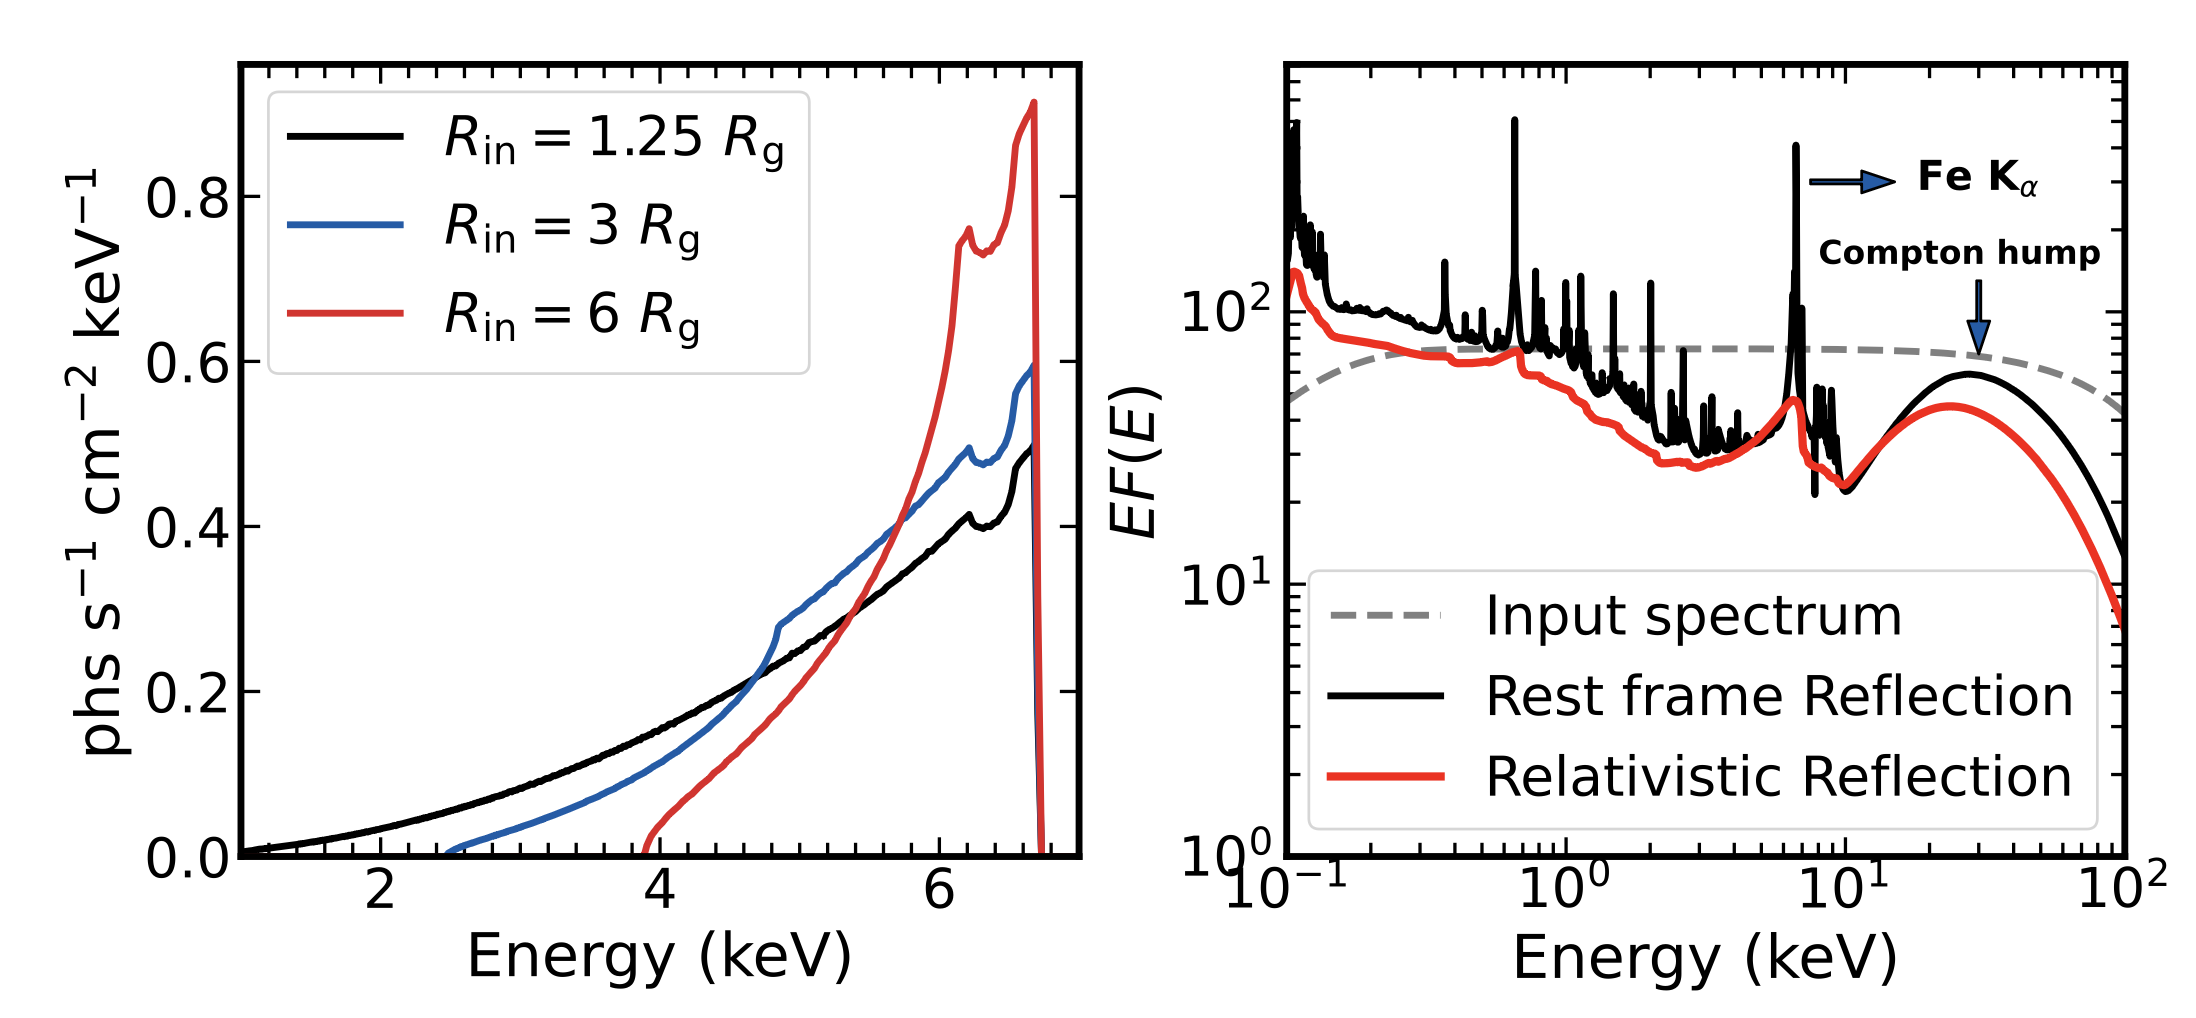

**Figure 2. (Left) The broadening of a 6.4 keV line by the accretion disk. (Right) The reflection spectrum in the rest-frame of the accretion disk (black) and the relativisticlly broadened observed spectrum (red).**

The X-ray reflection spectroscopy can be applied to **both X-ray binary and active galactic nuclei** systems.

## Models available 

### Broad line models

- `relline`: https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/node227.html
- `laor`: https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/node195.html
- `kynrline`: https://projects.asu.cas.cz/stronggravity/kyn#kynrline

### Local reflection models

- `xillver` and its variations (e.g., `xillverCp`, `xillverNS`): https://www.sternwarte.uni-erlangen.de/~dauser/research/relxill/.
    - The difference between these variations is the incident spectrum.
- `reflionx` and its variations: https://github.com/honghui-liu/reflionx_tables.
- `DAO`: https://github.com/ABHModels/DAO

### Convolution models for relativistic effects

- `relconv`. To use the model in XSPEC:
    - `relconv*xillver`.
    - `relconv*atable{reflionx_HD_nthcomp_v2_log.fits}`
    - In this configuration, the whole disk has the same density, ionization parameter and emission angle.
- `KYNconv`: https://projects.asu.cas.cz/stronggravity/kyn#kynconv

### Full reflection model

- `relxill`: https://www.sternwarte.uni-erlangen.de/~dauser/research/relxill/
    - Kerr spacetime with BH spins.
    - Other flavors: `relxillcp`, `relxilllp`, `relxilllpcp`, `relxillNS`, etc.
- `relxill_nk`: https://github.com/ABHModels/relxill_nk
    - In this model, the spacetime geometry near the BH can be **non-Kerr**.
- `KYNSTOKES`: https://projects.asu.cas.cz/dovciak/kynstokes
    - X-ray Relativistic reflection models with both **spectral and polarimetric** properties.
- `RELTRANS`: https://reltransdocs.readthedocs.io/en/latest/
    - X-ray Relativistic reflection models with both **spectral and reverberation lag** properties.
- `relfkerr`: https://users.camk.edu.pl/mitsza/reflkerr/

## Hands-on

In [2]:
import os
#import bxa.xspec as bxa
from IPython.display import display, HTML, Image

import xspec

%load_ext wurlitzer
import IPython.display

os.environ['HEADASNOQUERY'] = ''
os.environ['HEADASPROMPT'] = '/dev/null'

In [3]:
## Define functions for easy control and plot

import seaborn as sns
colors = sns.color_palette()

import matplotlib.pyplot as plt
import matplotlib
import numpy as np

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")


def delete_head(infile, skip_head=3):
    import subprocess as sp

    comm = f"sed -i -e \"1,{skip_head}d\" {infile}"
    sp.check_call(comm, shell=True)
    
    return True

def rewrite_ipl(infile:str):
    """
    Rewrite the output file of iplot in XSPEC. Each data group will be stored in
    the file 'temp-N.txt' (N starts from 0).

    Parameters:
    -----------
    infile: str
        The filename of the input file
    
    Output:
    -------
    Total number of files
    """
    j = 0
    fw = open('temp-0.txt','w+')
    with open(infile,'r') as f:
        for i in f:
            if (i.split()[0]=='NO'):
                fw.close()
                j = j + 1
                outfile=f"temp-{j}.txt"
                fw = open(outfile,'w+')
            else:
                fw.write(i)           
        fw.close()
    delete_head('temp-0.txt', skip_head=3)
    return j+1

def plot_format(ax, chi=True):
    ax.set_xscale('log')
    ax.set_xlim(1.0,100.0)

    ax.xaxis.set_ticks_position('both')
    #ax.xaxis.set_ticks_position('both')
    #ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    size=18
    ax.tick_params(axis='x',which='major', labelsize=size, direction='in', length=7, width=1.2)
    ax.tick_params(axis='x',which='minor', labelsize=size, direction='in', length=5, width=1.2)
    ax.tick_params(axis='y',which='major', labelsize=size, direction='in', length=7, width=1.2)
    ax.tick_params(axis='y',which='minor', labelsize=size, direction='in', length=5, width=1.2)

    ax.set_xlabel("Energy", fontsize=size+2)

def plot_eeuf_ra(nspec=1, naddmodel=2, delchi=False):
    save_data = 'specfit.qdp'
    if (os.path.isfile(save_data)):
        os.remove(save_data)
    
    xspec.Plot.commands = ()
    
    xspec.Plot.device = '/null'
    xspec.Plot.xAxis = "keV"
    xspec.Plot.add = True
    xspec.Plot.addCommand(f'wd {save_data}')

    if delchi:
        xspec.Plot("eeuf de") 
        hline = 0.0
        yl = "DelChi"
    else:
        xspec.Plot("eeuf ra") 
        hline= 1.0
        yl = "Data/Model"

    plt.close("all")
    fig = plt.figure(figsize=(8, 8)) 
    gs = matplotlib.gridspec.GridSpec(2, 1, height_ratios=[5, 2],hspace=0.0)
    ax = [None]*2

    i = 0
    for i in range(2):
        ax[i] = plt.subplot(gs[i])
        #ax[1] = plt.subplot(gs[1])

    rewrite_ipl(save_data)

    i = 0
    for i in range(nspec):
        infile = f"temp-{i}.txt"
        data = np.genfromtxt(infile, unpack=True, skip_header=0)
         
        
        ax[0].errorbar(x=data[0], y=data[2], xerr=data[1], yerr=data[3], lw = 1.0, ls='None',
                               color=colors[i], fmt='o', ms=5.0) 

        ax[0].plot(data[0], data[4], ls='-',lw=1.0, color=colors[i], label="Total")

        for j in range(naddmodel):
            ax[0].plot(data[0], data[5+j], ls='--',lw=1.0, color=colors[i])
        
        ax[0].set_yscale('log')

        infile = f"temp-{i+nspec}.txt"
        data = np.genfromtxt(infile, unpack=True, skip_header=0)
        ax[1].errorbar(x=data[0], y=data[2], xerr=data[1], yerr=data[3], lw = 1.0, ls='None',
                               color=colors[i], fmt='o', ms=5.0) 
        
    plot_format(ax[0])
    ax[0].tick_params(axis='x',which='major', labelsize=0)
    ax[0].tick_params(axis='x',which='minor', labelsize=0)
    ax[0].set_ylabel(r'keV$^2$ (phs cm$^{-2}$ s$^{-1}$ keV$^{-1}$)', fontsize=18)
    
    ax[1].set_ylabel(yl, fontsize=18)
    ax[1].axhline(y=hline, color='grey', ls='--', lw=1.5)
    plot_format(ax[1])

    return ax


def plot_ldat(nspec=1):
    save_data = 'specfit.qdp'
    if (os.path.isfile(save_data)):
        os.remove(save_data)
    
    xspec.Plot.commands = ()
    
    xspec.Plot.device = '/null'
    xspec.Plot.xAxis = "keV"
    xspec.Plot.add = True
    xspec.Plot.addCommand(f'wd {save_data}')

    xspec.Plot.area = True ## devided by effetive area
    xspec.Plot.setRebin(minSig=50, maxBins=10)
    xspec.Plot("ld") 

    plt.close("all")
    fig, ax = plt.subplots(figsize=(10,6))

    rewrite_ipl(save_data)
    
    for i in range(nspec):
        infile = f"temp-{i}.txt"
        data = np.genfromtxt(infile, unpack=True, skip_header=0)
         
        x = data[0]
        y = data[2]
        xerr = data[1].T  
        yerr = data[3].T

        ax.errorbar(x=x, y=y, xerr=xerr, yerr=yerr, lw = 1.0, ls='None',
                               color=colors[i], fmt='o', ms=5.0)  
        
        ax.set_yscale('log')
        ax.set_ylabel("Counts/s/keV/cm^2", fontsize=18)
        plot_format(ax)

# get_free: Get list of free parameters (corrected version)
def get_free():
    """
    Return and print a list of free parameter indices.
    """
    lis = []
    try:
        # Try to access the first model to check if any model is defined
        model = xspec.AllModels(1)
        nopar = model.nParameters  # Number of parameters in the first model
    except IndexError:
        raise ValueError("No model defined. Please define a model first (e.g., AllModels += 'pow').")

    # Iterate over parameters in the first model
    for j in range(1, nopar + 1):
        param = model(j)  # Access parameter by index
        if not param.frozen:  # Check if thawed
            if param.link=='': #Check if it is linked
                lis.append(j)
    print(lis)
    return lis


def error_free():
    # Save initial chi-square
    chi1 = xspec.Fit.statistic
    #xspec.Fit.query = "yes"
    xspec.Xset.parallel.error = 5
    lis = get_free()
    delchi = 2.706 
    # Save the current best-fit parameter values
    #best1 = get_best()
    for j in lis:
        xspec.Fit.error(f"stopat 20 0.01 maximum 100.0 {delchi},,{j}")
    chi2 = xspec.Fit.statistic
    #best2 = get_best()

    # Compare old and new best-fit values
    #print_old_new(best1, best2)

    print(f">>>Old chi^2: {chi1}")
    print(f">>>New chi^2: {chi2}")

    return chi1, chi2

### Load data

From FPMA and FPMB

In [4]:
os.chdir("../data/")
xspec.AllData("1:1 fpma_optmin20.pha 2:2 fpmb_optmin20.pha")

os.chdir("../notebooks/")


2 spectra  in use
 
Spectral Data File: fpma_optmin20.pha  Spectrum 1
Net count rate (cts/s) for Spectrum:1  2.769e+02 +/- 1.183e-01 (99.8 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-378
  Telescope: NuSTAR Instrument: FPMA  Channel Type: PI
  Exposure Time: 1.986e+04 sec
 Using fit statistic: chi
 Using Background File                nu30101022002A01_bk.pha
  Background Exposure Time: 1.986e+04 sec
 Using Response (RMF) File            nu30101022002A01_sr.rmf for Source 1
 Using Auxiliary Response (ARF) File  nu30101022002A01_sr.arf

Spectral Data File: fpmb_optmin20.pha  Spectrum 2
Net count rate (cts/s) for Spectrum:2  2.538e+02 +/- 1.115e-01 (99.7 % total)
 Assigned to Data Group 2 and Plot Group 2
  Noticed Channels:  1-370
  Telescope: NuSTAR Instrument: FPMB  Channel Type: PI
  Exposure Time: 2.05e+04 sec
 Using fit statistic: chi
 Using Background File                nu30101022002B01_bk.pha
  Background Exposure Time: 2.05e+04 sec
 Using Response

### Ingore uneffective energy ranges

In [5]:
xspec.AllData.ignore("*: **-3.0 79.0-**")

    10 channels (1-10) ignored in spectrum #     1
    10 channels (1-10) ignored in spectrum #     2
    97 channels (282-378) ignored in spectrum #     1
    87 channels (284-370) ignored in spectrum #     2

Fit statistic  : Chi-Squared              1.008206e+10     using 271 bins, spectrum 1, group 1.
                 Chi-Squared              1.002355e+10     using 273 bins, spectrum 2, group 2.
Total fit statistic                       2.010561e+10     with 537 d.o.f.

Test statistic : Chi-Squared              2.010561e+10     using 544 bins.
 Null hypothesis probability of 0.000000e+00 with 537 degrees of freedom
 Current data and model not fit yet.



### View the data

Plot command list is now empty
***Warning: Fit is not current.


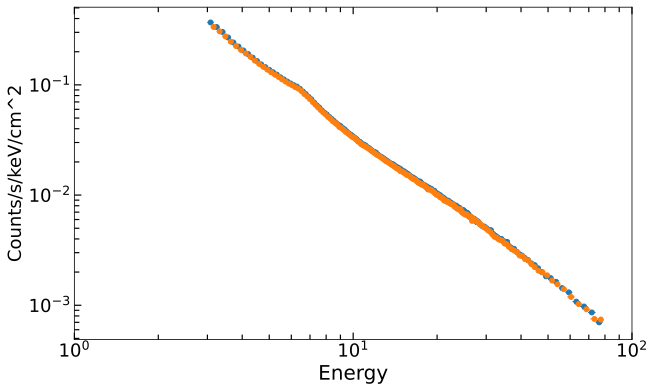

In [6]:
## Plot to see the raw data

plot_ldat(nspec=2)

### Load a simple continuum model

In [7]:
model = xspec.Model("const*tbabs*(diskbb+cutoffpl)")


Model constant<1>*TBabs<2>(diskbb<3> + cutoffpl<4>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
                           Data group: 1
   1    1   constant   factor              1.00000      +/-  0.0          
   2    2   TBabs      nH         10^22    1.00000      +/-  0.0          
   3    3   diskbb     Tin        keV      1.00000      +/-  0.0          
   4    3   diskbb     norm                1.00000      +/-  0.0          
   5    4   cutoffpl   PhoIndex            1.00000      +/-  0.0          
   6    4   cutoffpl   HighECut   keV      15.0000      +/-  0.0          
   7    4   cutoffpl   norm                1.00000      +/-  0.0          
                           Data group: 2
   8    1   constant   factor              1.00000      = p1
   9    2   TBabs      nH         10^22    1.00000      = p2
  10    3   diskbb     Tin        keV      1.00000      = p3
  11    3   diskbb     norm                1.00000      = p4
  12    4 

### Perform a fit

In [24]:
xspec.AllModels(1).setPars({1: "1.0 -0.1", 2:"0.6 -0.1"})
xspec.AllModels(2).setPars({1: "1.0 0.01"})

# perform a fit
xspec.Xset.abund = "wilm"

xspec.Fit.statMethod = 'chi'
xspec.Fit.query = 'yes'
xspec.Fit.statTest = 'chi'

xspec.Fit.renorm()
xspec.Fit.perform()


Fit statistic  : Chi-Squared                  338.28     using 271 bins, spectrum 1, group 1.
                 Chi-Squared                  343.68     using 273 bins, spectrum 2, group 2.
Total fit statistic                           681.96     with 532 d.o.f.

Test statistic : Chi-Squared                  681.96     using 544 bins.
 Null hypothesis probability of 1.09e-05 with 532 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                  338.28     using 271 bins, spectrum 1, group 1.
                 Chi-Squared                 4230.25     using 273 bins, spectrum 2, group 2.
Total fit statistic                          4568.53     with 532 d.o.f.

Test statistic : Chi-Squared                 4568.53     using 544 bins.
 Null hypothesis probability of 0.00e+00 with 532 degrees of freedom
 Current data and model not fit yet.
 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to ze

### View the residuals

Plot command list is now empty


(0.1, 43.792224447732075)

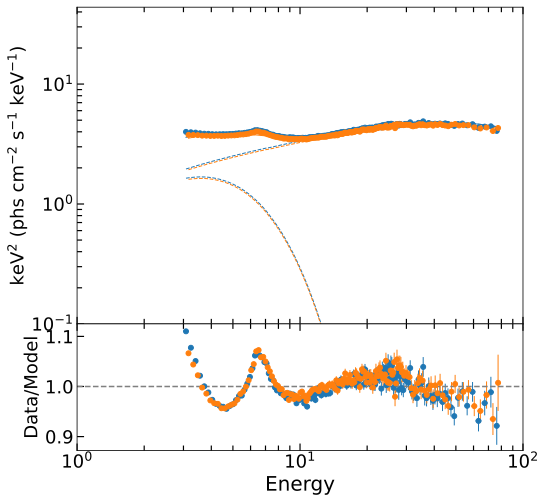

In [9]:
ax = plot_eeuf_ra(nspec=2, naddmodel=2, delchi=False)

ax[0].set_ylim(1e-1)

In the plot above, we can see that when fitting the data without a reflection model, there are large residuals around the **iron line** region (6-7 keV) and the **Compton hump** region (20-30 keV). To resolve these residuals, we should include a full reflection model (see below).

### Load the RELXILL package

In [10]:
# Load RELXILL model package

xspec.AllModels.lmod("relxill", '/Users/honghui/projects/models/relxill')

Model package relxill successfully loaded.


In [11]:
model2 = xspec.Model("const*tbabs*(diskbb+cutoffpl+relxill)")


Model constant<1>*TBabs<2>(diskbb<3> + cutoffpl<4> + relxill<5>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
                           Data group: 1
   1    1   constant   factor              1.00000      +/-  0.0          
   2    2   TBabs      nH         10^22    1.00000      +/-  0.0          
   3    3   diskbb     Tin        keV      1.00000      +/-  0.0          
   4    3   diskbb     norm                1.00000      +/-  0.0          
   5    4   cutoffpl   PhoIndex            1.00000      +/-  0.0          
   6    4   cutoffpl   HighECut   keV      15.0000      +/-  0.0          
   7    4   cutoffpl   norm                1.00000      +/-  0.0          
   8    5   relxill    Index1              3.00000      frozen
   9    5   relxill    Index2              3.00000      frozen
  10    5   relxill    Rbr                 15.0000      frozen
  11    5   relxill    a                   0.998000     +/-  0.0          
  12    5   relxil

In [12]:
xspec.AllModels(1).setPars({1: "1.0 -0.1", 2:"0.6 -0.1"})
xspec.AllModels(2).setPars({1: "1.0 0.01"})

xspec.AllModels(1).setPars({5: "=p16", 6:"=19", 9:"=p8"})
xspec.AllModels(1).setPars({8: "3.0 0.01", 19:"300.0 0.1", 20:"-1.0 -0.1"})


Fit statistic  : Chi-Squared              1.032585e+10     using 271 bins, spectrum 1, group 1.
                 Chi-Squared              1.026953e+10     using 273 bins, spectrum 2, group 2.
Total fit statistic                       2.059537e+10     with 532 d.o.f.

Test statistic : Chi-Squared              2.059537e+10     using 544 bins.
 Null hypothesis probability of 0.000000e+00 with 532 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared              1.032585e+10     using 271 bins, spectrum 1, group 1.
                 Chi-Squared              1.026953e+10     using 273 bins, spectrum 2, group 2.
Total fit statistic                       2.059537e+10     with 531 d.o.f.

Test statistic : Chi-Squared              2.059537e+10     using 544 bins.
 Null hypothesis probability of 0.000000e+00 with 531 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared              9.951712e+09     using 271 bins, spectrum 1, grou

In [13]:
xspec.AllModels.show()


Parameters defined:
Model constant<1>*TBabs<2>(diskbb<3> + cutoffpl<4> + relxill<5>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
                           Data group: 1
   1    1   constant   factor              1.00000      frozen
   2    2   TBabs      nH         10^22    0.600000     frozen
   3    3   diskbb     Tin        keV      1.00000      +/-  0.0          
   4    3   diskbb     norm                1.00000      +/-  0.0          
   5    4   cutoffpl   PhoIndex            2.00000      = p16
   6    4   cutoffpl   HighECut   keV      300.000      = p19
   7    4   cutoffpl   norm                1.00000      +/-  0.0          
   8    5   relxill    Index1              3.00000      +/-  0.0          
   9    5   relxill    Index2              3.00000      = p8
  10    5   relxill    Rbr                 15.0000      frozen
  11    5   relxill    a                   0.998000     +/-  0.0          
  12    5   relxill    Incl       deg 

### Perform a reflection fitting

In [14]:
xspec.Fit.renorm()
xspec.Fit.perform()


Fit statistic  : Chi-Squared                55529.85     using 271 bins, spectrum 1, group 1.
                 Chi-Squared                47949.58     using 273 bins, spectrum 2, group 2.
Total fit statistic                         103479.4     with 532 d.o.f.

Test statistic : Chi-Squared                103479.4     using 544 bins.
 Null hypothesis probability of 0.0e+00 with 532 degrees of freedom
 Current data and model not fit yet.
                                   Parameters
Chi-Squared  |beta|/N    Lvl         3:Tin        4:norm        7:norm      8:Index1          11:a       12:Incl      16:gamma      17:logxi        18:Afe       19:Ecut       21:norm     22:factor
100199       27495.5       1       1.74044      0.592688      0.100600       3.00116      0.998000       30.0180       2.00008       3.10021      0.998716       300.079      0.100125      0.999855
95087.1      59928.9       0       1.82179      0.743443      0.103002       3.01500      0.998000       30.2700       

### View the model and residuals

Plot command list is now empty


(0.1, 30.0)

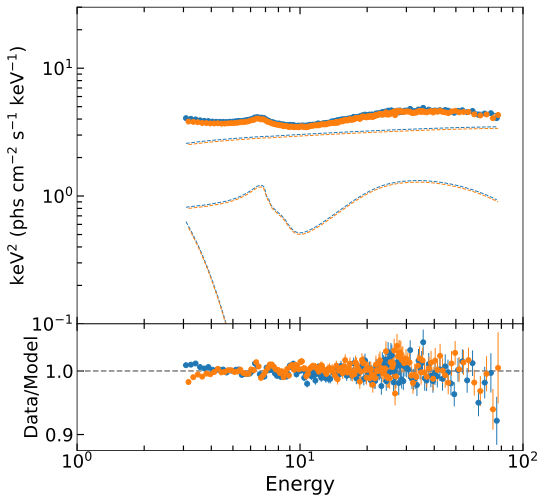

In [15]:
ax = plot_eeuf_ra(nspec=2, naddmodel=3, delchi=False)

ax[0].set_ylim(1e-1, 30.0)

Plot command list is now empty


(0.1, 30.0)

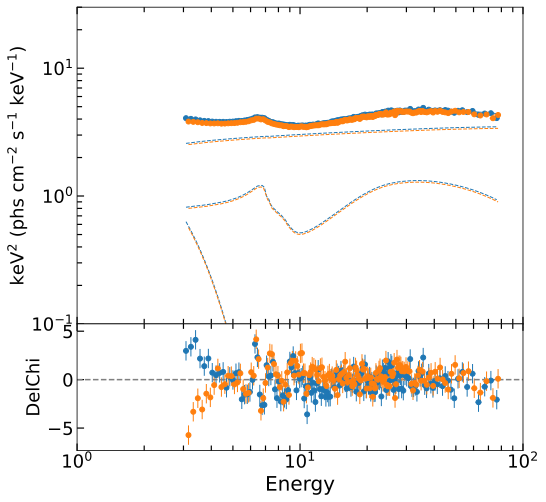

In [16]:
ax = plot_eeuf_ra(nspec=2, naddmodel=3, delchi=True)

ax[0].set_ylim(1e-1, 30.0)

In [17]:
get_free()

[3, 4, 7, 8, 11, 12, 16, 17, 18, 19, 21]


[3, 4, 7, 8, 11, 12, 16, 17, 18, 19, 21]

### Run `error` command

In [18]:
## Run `error` for each parameter to obtain the uncertainties.

# error_free()

## The upper command takes too much time,
## Uncomment and run the error command above and plotting command below.

# xspec.Fit.error(f"stopat 20 0.01 maximum 100.0 2.706,,11")

 Parameter   Confidence Range (2.706)
                                   Parameters
Chi-Squared  |beta|/N    Lvl         3:Tin        4:norm        7:norm      8:Index1          11:a       12:Incl      16:gamma      17:logxi        18:Afe       19:Ecut       21:norm     22:factor
757.043      24.8394      -3      0.548707       3377.71       2.36098       2.71777      0.929657       30.4739       1.87166       3.30541       5.04087       517.071     0.0210667      0.972144
755.976      488.237      -1      0.548895       3387.88       2.36036       2.71573      0.928876       30.4032       1.87169       3.30481       5.00555       520.160     0.0210577      0.972121
755.937      56.4814      -1      0.548922       3389.17       2.36024       2.71449      0.929581       30.3675       1.87164       3.30463       5.00798       520.955     0.0210544      0.972137
755.916      147.591      -2      0.549191       3384.80       2.35923       2.71438      0.929749       30.3450       1.87125  

Plot command list is now empty


(0.1, 30.0)

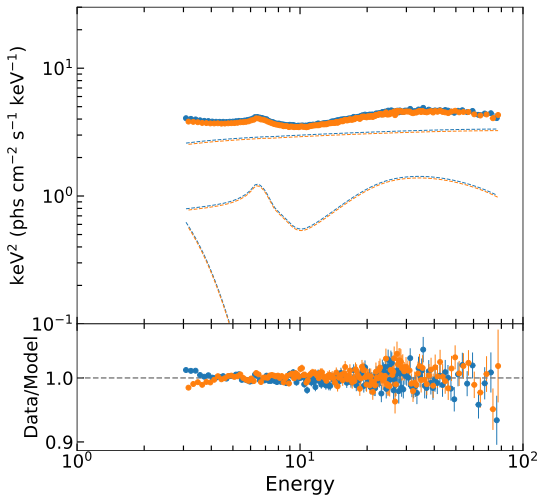

In [19]:
ax = plot_eeuf_ra(nspec=2, naddmodel=3, delchi=False)

ax[0].set_ylim(1e-1, 30.0)

Plot command list is now empty


(0.1, 30.0)

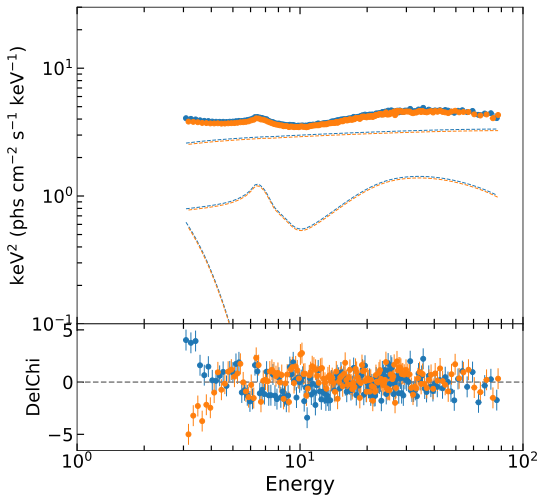

In [20]:
ax = plot_eeuf_ra(nspec=2, naddmodel=3, delchi=True)

ax[0].set_ylim(1e-1, 30.0)

Plot command list is now empty


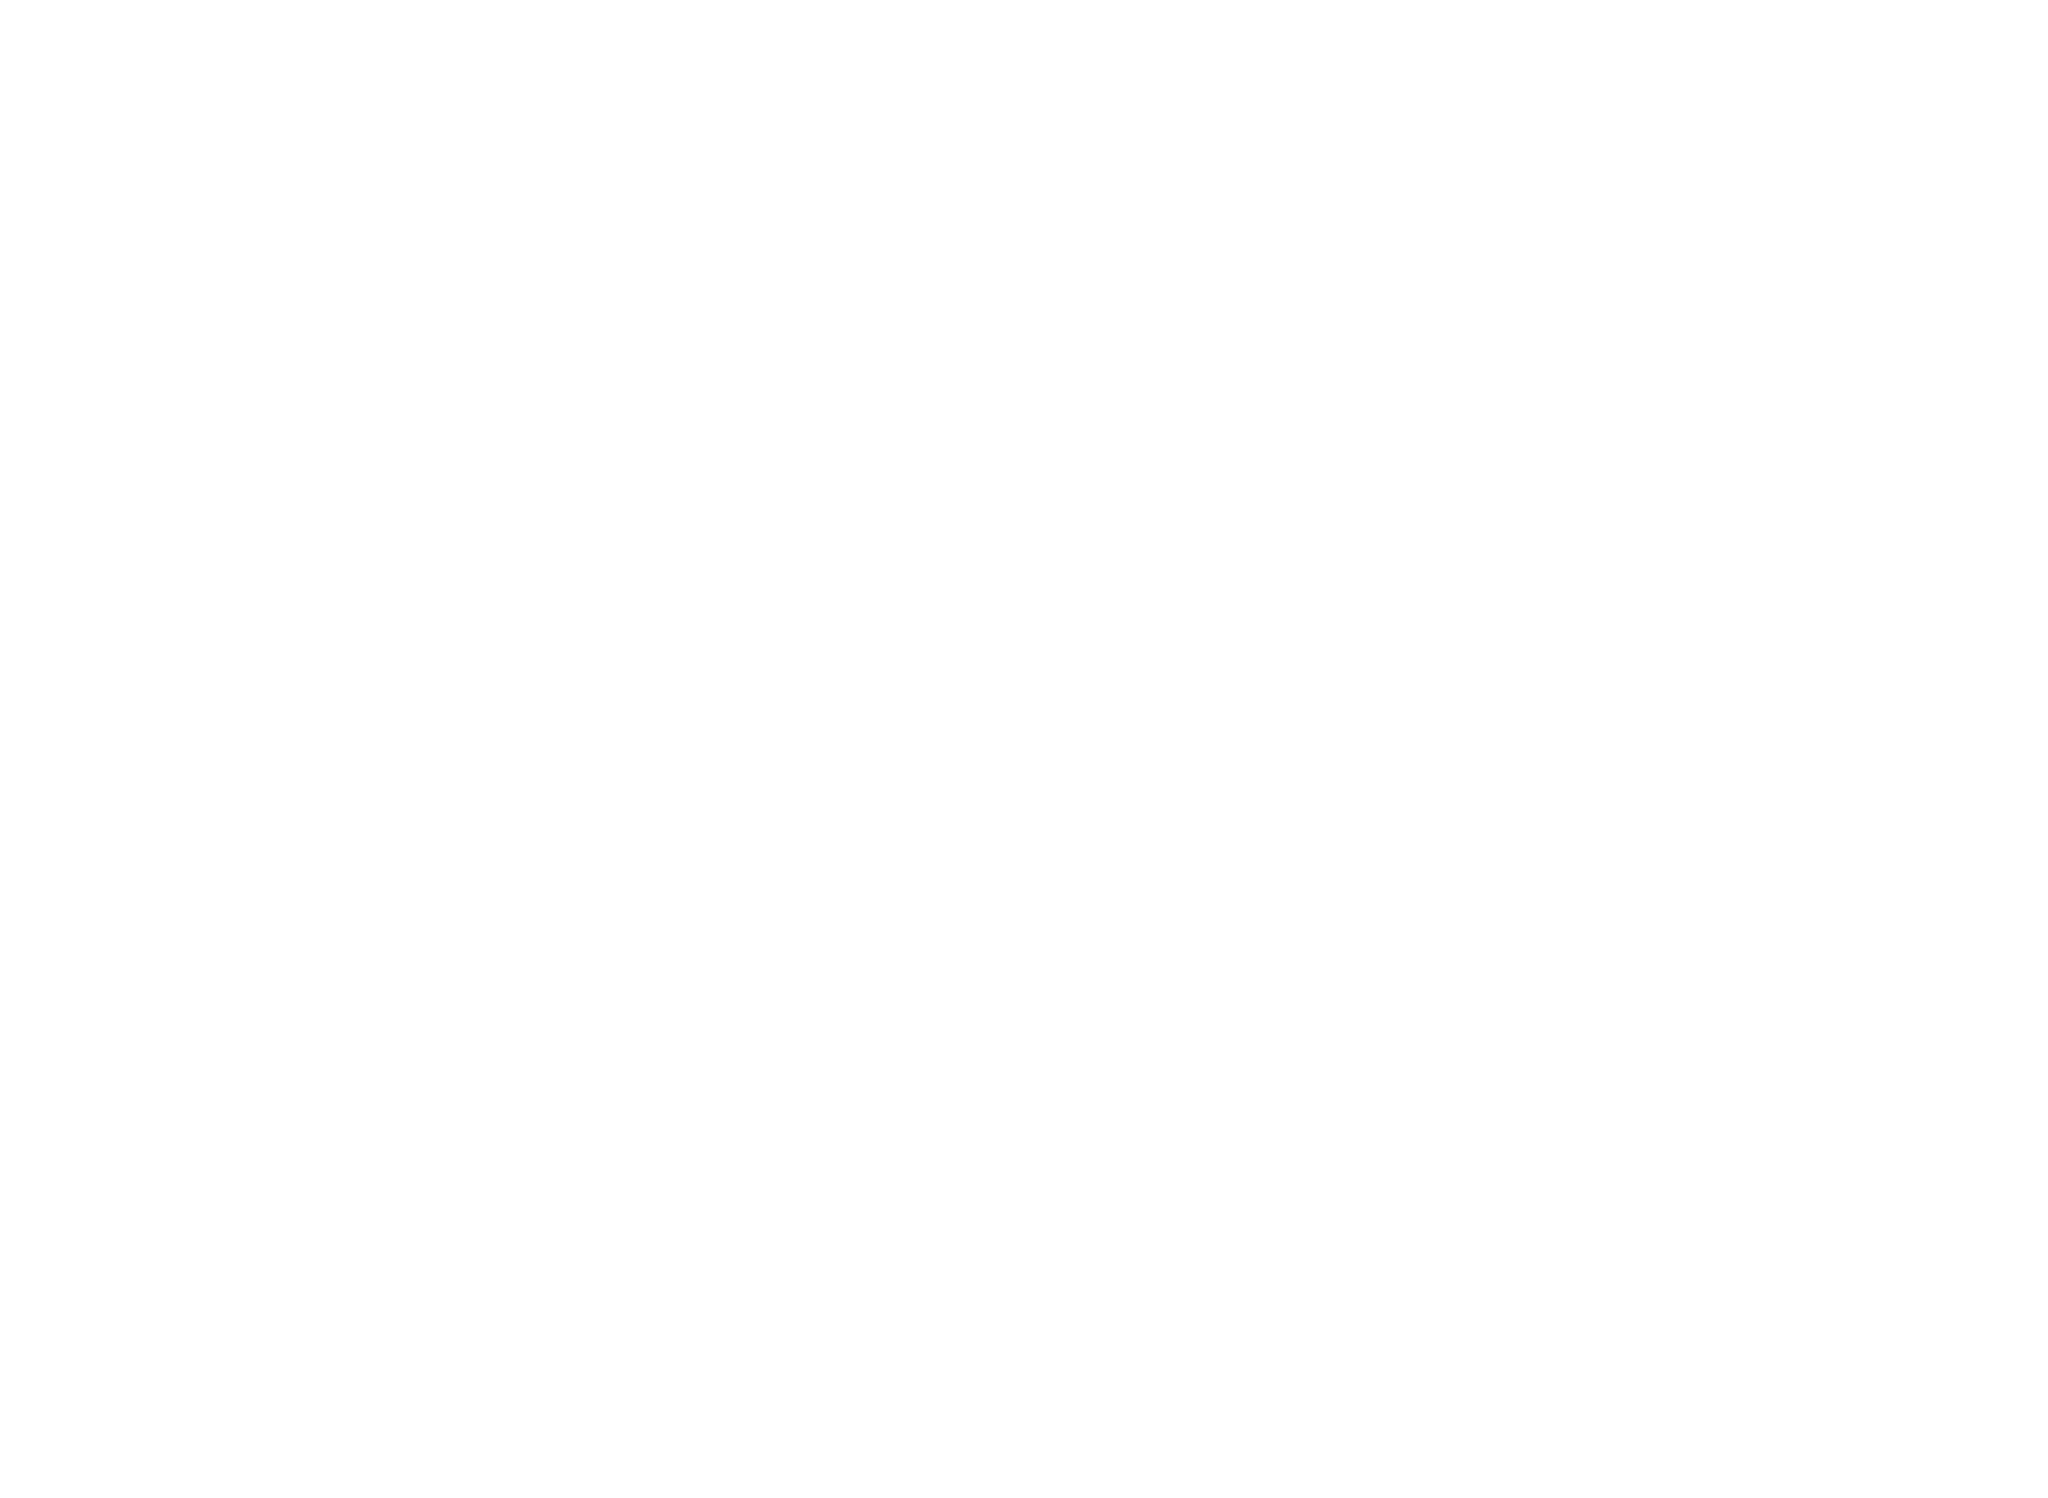

In [23]:
# An easier way to make plot

xspec.Plot.commands = ()
xspec.Plot.device="/svg"
#xspec.Plot.addCommand("log y")
xspec.Plot("eeuf ra")

## Some advice

Note that this tutorial only gives an minimal example of reflection fitting. It has no guarantee that the results shown here is the final best-fit. Due to the complexity of reflection models, the fitting can easily be traped in local minimums. 

It is recommended to run `steppar` on each parameter or even pairs of parameters to check for lower minimums. Running `error` command sometimes also helps to find better fit.

Some guidelines to assess a fitting:

1. Are there any residuals in the ratio plot?
2. Are all parameters constrained? How are the parameters degenerated, e.g., MCMC simulation?
3. Are the parameters physically acceptable?
4. Are the parameters consistent with literature? If not, why?
5. Are the results model-dependent? For example, if changing flavors of the reflection model, how does the parameters change?